# Lab KF5 - Radiation in the environment

*This document is to help you perform the analysis. In order to save changes that you make, remember to save the document before closing it! You may include it as an appendix to your lab reports and it will not counts towards the max. 10 pages limit* 

**In the code cells, whenever you see the comment " -> TODO <- " This means that you need to edit or add something to that row in the code. Read the relevant comment which follows.**

### Importing python packages <a name="import"></a>

In [2]:
#This code cell holds useful code neede for the analysis. Execute it like normal.
# Packages to help importing files 
import sys, os

# Package that supports working with large arrays
import numpy as np  
import pandas as pd

# math
from math import sqrt

# Package for plotting 
import matplotlib   # choose a backend for web applications; remove for stand-alone applications:
matplotlib.use('Agg') # enable interactive notebook plots (alternative: use 'inline' instead of 'notebook'/'widget' for static images)
%matplotlib inline

# The following line is the ONLY one needed in stand-alone applications!
import matplotlib.pyplot as plt

# Function that fits a curve to data 
from scipy.optimize import curve_fit

# For uncertainties calculations
from uncertainties import ufloat, ufloat_fromstr, unumpy
from uncertainties.umath import * # sin(), etc...

# Custom pakages prepared for you to analyze experimental data from labs.
# The code is located in the 'lib' subfolder which we have to specify:
sys.path.append('./lib')
import MCA
import fittingFunctions

# Part 1: Ambient dose measurement

Please estimate **properly** the average of your measurements. You can refer to the `Uncertainties` Jyputer notebook on how to avegare quantities which include _different_ uncertainties.
 

## Task 1.3 Analysis of the dose measurement results 

In [ ]:
#-> TODO <- Compute the average of the Ambient dose measurements for each location.

#Outside 1
avg_ambient_dose_outside_1 = np.mean([0.20, 0.21, 0.22, 0.21])
#Outside 2
avg_ambient_dose_outside_2 = np.mean([0.11, 0.11])
#Outside 3
avg_ambient_dose_outside_3 = np.mean([0.11, 0.13])


#Inside 1
avg_ambient_dose_inside_1 = np.mean([0.11, 0.12, 0.11 , 0.10])
#Inside 2
avg_ambient_dose_inside_2 = np.mean([0.11, 0.13])
#Inside 3
avg_ambient_dose_inside_3 = np.mean([0.12, 0.12])

#Uncertainty of the ambient dose measurements
#Outside 1
uncertainty_outside_1 = np.std([0.20, 0.21, 0.22, 0.21], ddof=1) / sqrt(4)
#Outside 2
uncertainty_outside_2 = np.std([0.11, 0.11], ddof=1) / sqrt(2)
#Outside 3
uncertainty_outside_3 = np.std([0.11, 0.13], ddof=1) / sqrt(2)

#Inside 1
uncertainty_inside_1 = np.std([0.11, 0.12, 0.11 , 0.10], ddof=1) / sqrt(4)
#Inside 2
uncertainty_inside_2 = np.std([0.11, 0.13], ddof=1) / sqrt(2)
#Inside 3
uncertainty_inside_3 = np.std([0.12, 0.12], ddof=1) / sqrt(2)

print("Average ambient dose measurements:")
print(f"Outside 1: {avg_ambient_dose_outside_1:.2f} ± {uncertainty_outside_1:.3f} μSv/h")
print(f"Outside 2: {avg_ambient_dose_outside_2:.2f} ± {uncertainty_outside_2:.3f} μSv/h")
print(f"Outside 3: {avg_ambient_dose_outside_3:.2f} ± {uncertainty_outside_3:.3f} μmv/h")
print(f"Inside 1: {avg_ambient_dose_inside_1:.2f} ± {uncertainty_inside_1:.3f} μSv/h")  
print(f"Inside 2: {avg_ambient_dose_inside_2:.2f} ± {uncertainty_inside_2:.3f} μSv/h")  
print(f"Inside 3: {avg_ambient_dose_inside_3:.2f} ± {uncertainty_inside_3:.3f} μSv/h")  


Average ambient dose measurements:
Outside 1: 0.210 ± 0.004 μSv/h
Outside 2: 0.110 ± 0.000 μSv/h
Outside 3: 0.120 ± 0.010 μmv/h
Inside 1: 0.110 ± 0.004 μSv/h
Inside 2: 0.120 ± 0.010 μSv/h
Inside 3: 0.120 ± 0.000 μSv/h


In [13]:
#-> TODO <- Compute the annual effective dose rate [mSv/y] on each location

#Assuming 8760 hours in a year
Years_in_hours = 8760
#Outside 1
annual_effective_dose_outside_1 = avg_ambient_dose_outside_1 * Years_in_hours / 1000  # Convert μSv/h to mSv/y
#Outside 2
annual_effective_dose_outside_2 = avg_ambient_dose_outside_2 * Years_in_hours / 1000 
#Outside 3
annual_effective_dose_outside_3 = avg_ambient_dose_outside_3 * Years_in_hours / 1000
#Inside 1
annual_effective_dose_inside_1 = avg_ambient_dose_inside_1 * Years_in_hours / 1000
#Inside 2
annual_effective_dose_inside_2 = avg_ambient_dose_inside_2 * Years_in_hours / 1000
#Inside 3
annual_effective_dose_inside_3 = avg_ambient_dose_inside_3 * Years_in_hours / 1000 

print("\nAnnual effective dose rates:")
print(f"Outside 1: {annual_effective_dose_outside_1:.3f} mSv/y")
print(f"Outside 2: {annual_effective_dose_outside_2:.3f} mSv/y")
print(f"Outside 3: {annual_effective_dose_outside_3:.3f} mSv/y")
print(f"Inside 1: {annual_effective_dose_inside_1:.3f} mSv/y")
print(f"Inside 2: {annual_effective_dose_inside_2:.3f} mSv/y")
print(f"Inside 3: {annual_effective_dose_inside_3:.3f} mSv/y")



Annual effective dose rates:
Outside 1: 1.840 mSv/y
Outside 2: 0.964 mSv/y
Outside 3: 1.051 mSv/y
Inside 1: 0.964 mSv/y
Inside 2: 1.051 mSv/y
Inside 3: 1.051 mSv/y


In [35]:
#-> TODO <- Estimate the contribution from radon (%) to the dose you measured indoors. 
Long_term_avg = 5 #Bq/m³

conversion_factor_agency1 = 6.7e-6  # mSv/y per Bq/m³
conversion_factor_agency2 = 0.8e-6  # mSv/y per Bq/m³
# Calculate the radon contribution to the annual effective dose
radon_contribution_agency1 = Long_term_avg * conversion_factor_agency1 * Years_in_hours 
radon_contribution_agency2 = Long_term_avg * conversion_factor_agency2 * Years_in_hours   

# Calculate the percentage contribution of radon to the indoor dose
percentage_contribution_agency1 = (radon_contribution_agency1 / annual_effective_dose_inside_1) * 100
percentage_contribution_agency2 = (radon_contribution_agency2 / annual_effective_dose_inside_1) * 100
print("\nRadon contribution to indoor dose:")
print(f"Using Agency 1 conversion factor: {radon_contribution_agency1:.3f} mSv/y ({percentage_contribution_agency1:.2f}%)")
print(f"Using Agency 2 conversion factor: {radon_contribution_agency2:.3f} mSv/y ({percentage_contribution_agency2:.2f}%)")



Radon contribution to indoor dose:
Using Agency 1 conversion factor: 0.293 mSv/y (30.45%)
Using Agency 2 conversion factor: 0.035 mSv/y (3.64%)


Looking at the radiation atlas: The avarage dose in Lund seems to be $0.5 mSv$  from the ground and $<350 \mu Sv$ from Cosmic-Rays. At the very highest, our model is roughly $0.1mSv$  to high, at the lowest $0.5 mSv$. Our calculated annual dose is also lower than the legal annual dose for both workers and regular people.

New hypothesis: The concentration of Radon is constant throughout Fysicum. How much of calculated radiation dose is contributed from Radon?

# Part 2 : $\alpha$ Spectrometry

## Task 2.2: Calibrate Detector

### Step 1: Import your data and plot the spectrum in Jupyter Notebook

In [76]:
#Load your data files here:
Th228 = MCA.load_spectrum("thorium-228_spectrum.Spe") #-> TODO <- Insert the name of your data file. Source: Th-228

(0.0, 300.0)

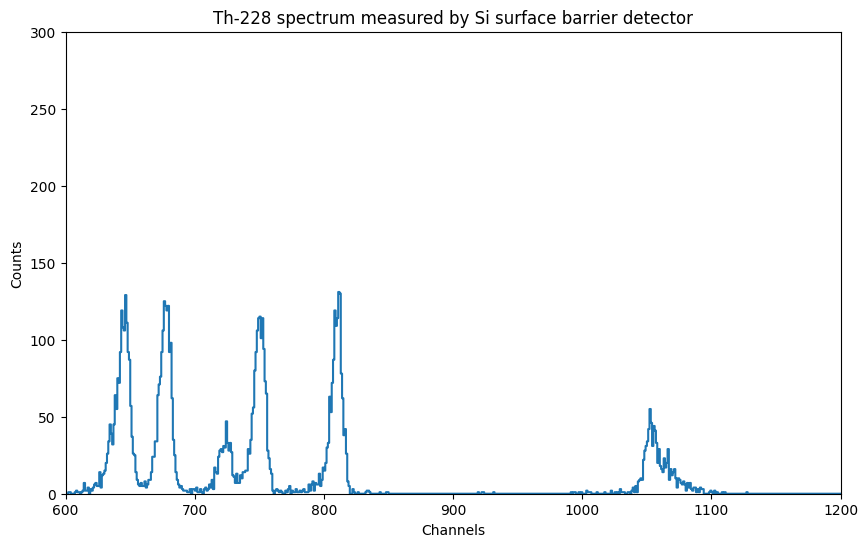

In [89]:
#Execute this cell to make plot of Th-228 spectra

#### NO NEED TO EDIT ####
plt.figure(0, figsize=(10, 6)) #make figure for Th-228 data.
plt.step(Th228.bin_centers, Th228.counts, where='mid', label='step') #make a stepped plot
plt.title("Th-228 spectrum measured by Si surface barrier detector") # set title of the plot
plt.xlabel("Channels")     # set label for x-axis 
plt.ylabel("Counts")       # set label for y-axis 
#plt.yscale('log')          # show the y-axis in logarithmic scale
plt.xlim(xmin=600, xmax=1200)    # -> TODO <- Might need to tune the axis scale [energy]
plt.ylim(ymin=0, ymax=300)
#plt.savefig("test_spectrum.png") #This is how you can save the figure
#########################

### Step 2: Fit a Gaussian function to the relevant peaks and save the centroid values (we will use these for calibration in the next task).

A gaussian function looks like this:
$$G(x) = A\cdot e^{\frac{(x-\mu)^2}{2\sigma^2}}$$
where
- $A$ is a constant determing the amplitude of the peak, 
- $\mu$ is the mean value of the peak (centroid),
- $\sigma$ is the standard diviation of the peak (width of the peak).

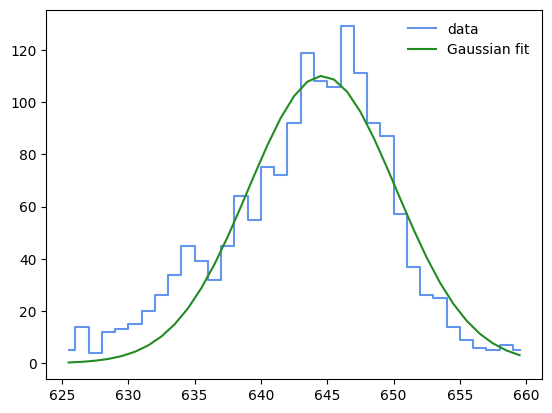

Estimated parameters:
 A = 110.06580, mu = 644.62441,  sigma = 5.56791 

Uncertainties in the estimated parameters: 
 σ²(A) = 22.98876, σ²(mu) = 0.07838, σ²(sigma) = 0.07880 

Covariance matrix: 
 [[ 2.29887554e+01 -1.46622300e-03 -7.78292305e-01]
 [-1.46622300e-03  7.83781311e-02  1.69133632e-04]
 [-7.78292305e-01  1.69133632e-04  7.88028374e-02]]


In [100]:
# Fitting the 1st peak:

# In order to make a fit the software needs an intial guess of the parameters of the gaussian.
first_peak = fittingFunctions.perform_Gaussian_fit(x=Th228.bin_centers, # your x data 
                                              y=Th228.counts,           # your y data 
                                              region_start=625,   # -> TODO <- Insert channel number from where to START fitting.
                                              region_stop=660,    # -> TODO <- Insert channel number from where to STOP fitting.
                                              mu_guess=648,       # -> TODO <- Insert intial guess of peak centroid (mean value of the peak)
                                              A_guess=120,        # -> TODO <- Insert intial guess for the constant 'A' (amplitude of the peak)
                                              sigma_guess=9)    # -> TODO <- Insert intial guess for the standard diviation (width of the peak)

#After executing this cell (Shift + Enter) the fitted parameters can be seen below the plot.

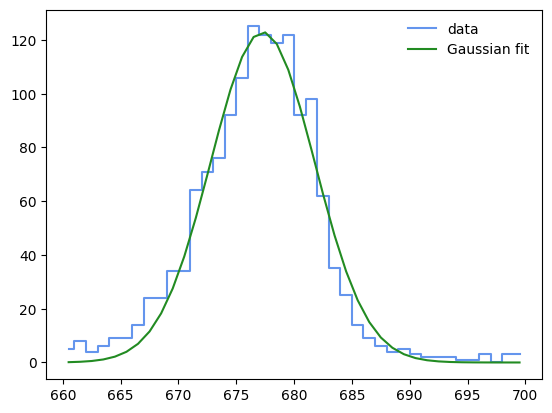

Estimated parameters:
 A = 122.94482, mu = 677.28183,  sigma = 4.49681 

Uncertainties in the estimated parameters: 
 σ²(A) = 9.25849, σ²(mu) = 0.01651, σ²(sigma) = 0.01651 

Covariance matrix: 
 [[ 9.25848954e+00  1.14026150e-06 -2.25759155e-01]
 [ 1.14026150e-06  1.65144541e-02 -6.80738507e-08]
 [-2.25759155e-01 -6.80738507e-08  1.65146334e-02]]


In [102]:
# Fitting the 2nd peak:

# In order to make a fit the software needs an intial guess of the parameters of the gaussian.
second_peak = fittingFunctions.perform_Gaussian_fit(x=Th228.bin_centers, # your x data 
                                              y=Th228.counts,           # your y data 
                                              region_start=660,   # -> TODO <- Insert channel number from where to START fitting.
                                              region_stop=700,    # -> TODO <- Insert channel number from where to STOP fitting.
                                              mu_guess=677,       # -> TODO <- Insert intial guess of peak centroid (mean value of the peak)
                                              A_guess=120,        # -> TODO <- Insert intial guess for the constant 'A' (amplitude of the peak)
                                              sigma_guess=9)    # -> TODO <- Insert intial guess for the standard diviation (width of the peak)

#After executing this cell (Shift + Enter) the fitted parameters can be seen below the plot.

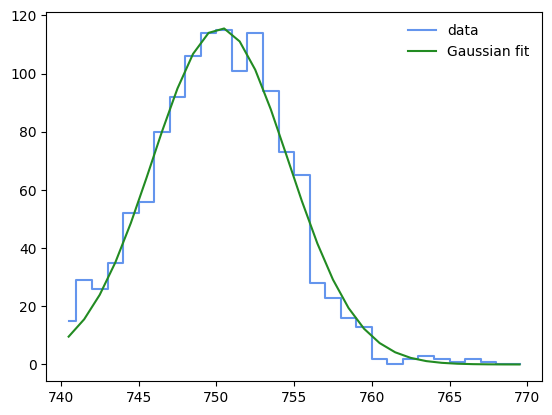

Estimated parameters:
 A = 115.66203, mu = 750.25028,  sigma = 4.36725 

Uncertainties in the estimated parameters: 
 σ²(A) = 7.02230, σ²(mu) = 0.01332, σ²(sigma) = 0.01369 

Covariance matrix: 
 [[ 7.02229615e+00  2.03486711e-03 -1.80288502e-01]
 [ 2.03486711e-03  1.33231235e-02 -1.83756881e-04]
 [-1.80288502e-01 -1.83756881e-04  1.36862208e-02]]


In [104]:
# Fitting the 3rd peak:

# In order to make a fit the software needs an intial guess of the parameters of the gaussian.
third_peak = fittingFunctions.perform_Gaussian_fit(x=Th228.bin_centers, # your x data 
                                              y=Th228.counts,           # your y data 
                                              region_start=740,   # -> TODO <- Insert channel number from where to START fitting.
                                              region_stop=770,    # -> TODO <- Insert channel number from where to STOP fitting.
                                              mu_guess=750,       # -> TODO <- Insert intial guess of peak centroid (mean value of the peak)
                                              A_guess=120,        # -> TODO <- Insert intial guess for the constant 'A' (amplitude of the peak)
                                              sigma_guess=9)    # -> TODO <- Insert intial guess for the standard diviation (width of the peak)

#After executing this cell (Shift + Enter) the fitted parameters can be seen below the plot.

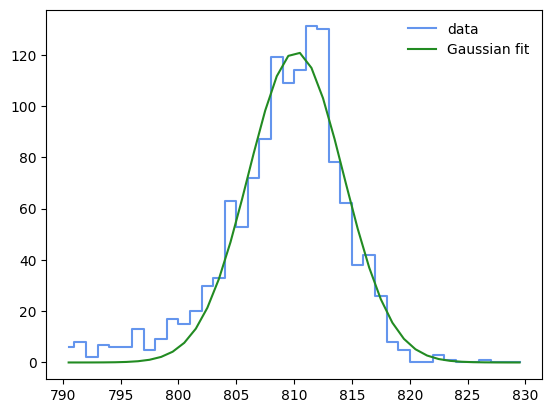

Estimated parameters:
 A = 121.10100, mu = 810.16269,  sigma = 4.11261 

Uncertainties in the estimated parameters: 
 σ²(A) = 16.92138, σ²(mu) = 0.02602, σ²(sigma) = 0.02602 

Covariance matrix: 
 [[ 1.69213816e+01  1.12456184e-06 -3.83106670e-01]
 [ 1.12456184e-06  2.60210534e-02 -3.81766571e-08]
 [-3.83106670e-01 -3.81766571e-08  2.60210531e-02]]


In [106]:
# Fitting the 4th peak:

# In order to make a fit the software needs an intial guess of the parameters of the gaussian.
fourth_peak = fittingFunctions.perform_Gaussian_fit(x=Th228.bin_centers, # your x data 
                                              y=Th228.counts,           # your y data 
                                              region_start=790,   # -> TODO <- Insert channel number from where to START fitting.
                                              region_stop=830,    # -> TODO <- Insert channel number from where to STOP fitting.
                                              mu_guess=811,       # -> TODO <- Insert intial guess of peak centroid (mean value of the peak)
                                              A_guess=120,        # -> TODO <- Insert intial guess for the constant 'A' (amplitude of the peak)
                                              sigma_guess=9)    # -> TODO <- Insert intial guess for the standard diviation (width of the peak)

#After executing this cell (Shift + Enter) the fitted parameters can be seen below the plot.

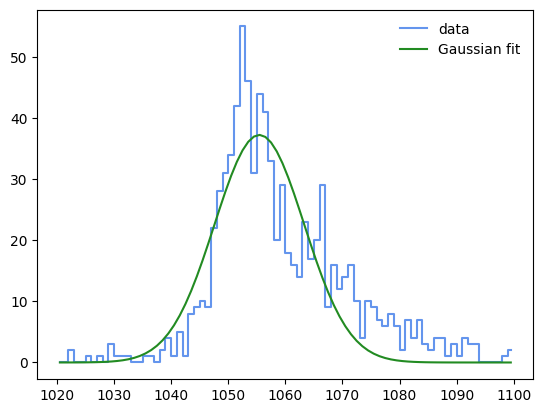

Estimated parameters:
 A = 37.25300, mu = 1055.44778,  sigma = 7.85685 

Uncertainties in the estimated parameters: 
 σ²(A) = 3.81573, σ²(mu) = 0.22633, σ²(sigma) = 0.22633 

Covariance matrix: 
 [[ 3.81573122e+00  1.08283243e-06 -5.36531754e-01]
 [ 1.08283243e-06  2.26325917e-01 -2.30164964e-07]
 [-5.36531754e-01 -2.30164964e-07  2.26325935e-01]]


In [118]:
# Fitting the 5th peak:

# In order to make a fit the software needs an intial guess of the parameters of the gaussian.
fifth_peak = fittingFunctions.perform_Gaussian_fit(x=Th228.bin_centers, # your x data 
                                              y=Th228.counts,           # your y data 
                                              region_start=1020,   # -> TODO <- Insert channel number from where to START fitting.
                                              region_stop=1100,    # -> TODO <- Insert channel number from where to STOP fitting.
                                              mu_guess=1050,       # -> TODO <- Insert intial guess of peak centroid (mean value of the peak)
                                              A_guess=50,        # -> TODO <- Insert intial guess for the constant 'A' (amplitude of the peak)
                                              sigma_guess=12)    # -> TODO <- Insert intial guess for the standard diviation (width of the peak)

#After executing this cell (Shift + Enter) the fitted parameters can be seen below the plot.

### Step 3: Create an energy calibration curve. 

Recall that the energy calibration is the linear dependence between the MCA channel number and the energies of the identified full-energy peaks. It is performed with a linear function.

A linear function looks like:
$$Energy = k \cdot Channel + m$$
where;
- $k$ determines the slope of the curve,
- $m$ determined the intersection of the y-axis.

Find calibration constants for Si detector: 

Alpha energies [MeV]: [5.42 5.68 6.28 6.78 8.78]
Fitted centroid values [ADC]: [ 644.62440921  677.28182929  750.25028235  810.16269392 1055.44778304]


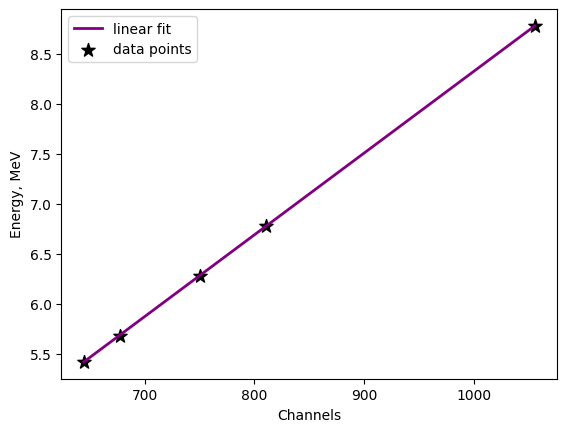

Estimated paramters (k, m) = (0.00819, 0.13894)


In [120]:
#First, lets put in the relevant alpha energies
#Information can be found from 232Th-chart.pdf
Table_E_1 = np.asarray([5.42])           # -> TODO <- Insert energy [MeV] of the first peak
Table_E_2 = np.asarray([5.68])           # -> TODO <- Insert energy [MeV] of the second peak
Table_E_3 = np.asarray([6.28])           # -> TODO <- Insert energy [MeV] of the third peak
Table_E_4 = np.asarray([6.78])           # -> TODO <- Insert energy [MeV] of the fourth peak
Table_E_5 = np.asarray([8.78])           # -> TODO <- Insert energy [MeV] of the fifth peak


#### NO NEED TO EDIT ####
Table_E = np.concatenate([Table_E_1,Table_E_2,Table_E_3,Table_E_4,Table_E_5]) #put all energies into one container 'Table_E' for ease of use
mu_peak1 = np.asarray([first_peak.mu]) #save fitted centroid value
mu_peak2 = np.asarray([second_peak.mu]) #save fitted centroid value
mu_peak3 = np.asarray([third_peak.mu]) #save fitted centroid value
mu_peak4 = np.asarray([fourth_peak.mu]) #save fitted centroid value
mu_peak5 = np.asarray([fifth_peak.mu]) #save fitted centroid value

mu_calibration = np.concatenate([mu_peak1,mu_peak2,mu_peak3,mu_peak4,mu_peak5]) #put all fitted centroid values in one container 'mu_calibration' for ease of use

print(f'Alpha energies [MeV]: {Table_E}')
print(f'Fitted centroid values [ADC]: {mu_calibration}')
#########################

# Same as before, the linear function needs intial guess for the two paramters:
k_guess = 2 # -> intial guess for the slope of the curve
m_guess = 1 # -> initial guess for the intersection of the y-axis

#### NO NEED TO EDIT ####
# Perform the fit
estimates_NaI, covar_matrix = curve_fit(fittingFunctions.LineFunc, # name of the function - linear function in our case
                                        mu_calibration,            # our x data - peak centroids 
                                        Table_E,                   # our y data - energies
                                        p0 = [k_guess, m_guess])   # our initial guessesfor k and m parameters

k = estimates_NaI[0] #save fitted parameter 'k' 
m = estimates_NaI[1] #save fitted parameter 'm'
plt.figure() #make figure 
plt.plot(mu_calibration, fittingFunctions.LineFunc(mu_calibration, estimates_NaI[0], estimates_NaI[1]), color='purple', lw=2, label='linear fit') #plot the linear fit
plt.scatter(mu_calibration, Table_E, s=100, c='black', marker='*', label='data points') #plot the fitted data
plt.legend(loc='upper left') #set a legend and its position
plt.xlabel("Channels")       # set label for x-axis 
plt.ylabel("Energy, MeV")    # set label for y-axis 
plt.show()
print(f"Estimated paramters (k, m) = ({round(k, 5)}, {round(m, 5)})") #print the results of the fit to screen
#########################

#After executing this cell (Shift + Enter) the fitted parameters can be seen below the plot.

### Step 4: Plot the calibrated data and check that the peaks have the correct energy.

In [121]:
#Execute to calibrate from ADC channels to Energy [MeV] for the two data sets.

#### NO NEED TO EDIT ####
Th228.calibrate(k,m) #calibrate the Th-228 spectra

#########################

(0.0, 200.0)

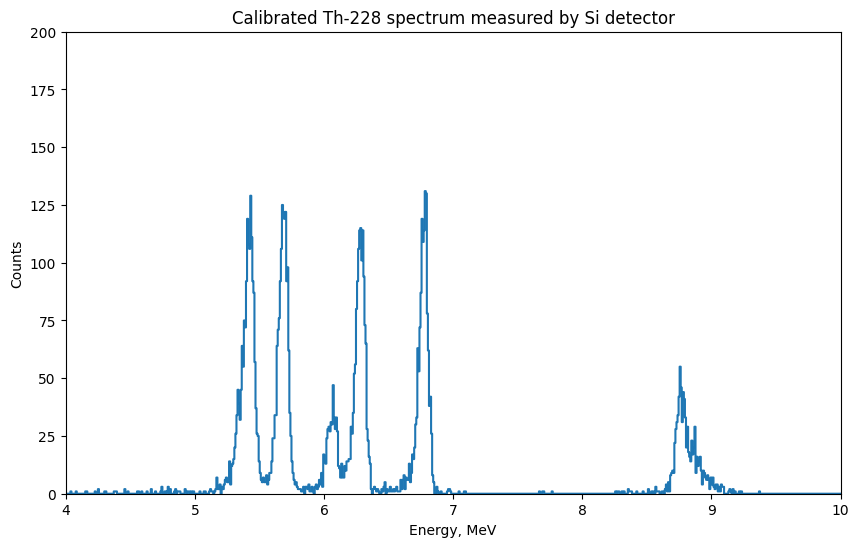

In [130]:
#Execute to make plot of calibrated Th-228 spectra

#### NO NEED TO EDIT ####
plt.figure(figsize=(10, 6))
# with the data read in with the first routine
plt.step(Th228.energy, Th228.counts, where='mid', label='step')
plt.title("Calibrated Th-228 spectrum measured by Si detector") # set title of the plot
plt.xlabel("Energy, MeV")     # set label for x-axis 
plt.ylabel("Counts")       # set label for y-axis 
plt.xlim(xmin=4, xmax=10)    # -> TODO <- Might need to tune the axis scale [energy]
plt.ylim(ymin=0, ymax=200)
#plt.savefig("th228_calib_spectrum.png") #This is how you save the figure
#########################

## Task 2.3: Characterise the detector

### Step 1: Import the data from the energy calibration source (Am-241)

In [131]:
#Load your data file here:
Calib_source = MCA.load_spectrum("Am-241_spectrum.Spe") #-> TODO <- Insert the name of your data file. Source: Calibration source

In [132]:
#Now we can use your previous calibration to calibrate this new spectra!

#### NO NEED TO EDIT ####
Calib_source.calibrate(k, m)
#########################

### Step 2: Plot the uncalibrated and calibrated spectra of the Am-241 source

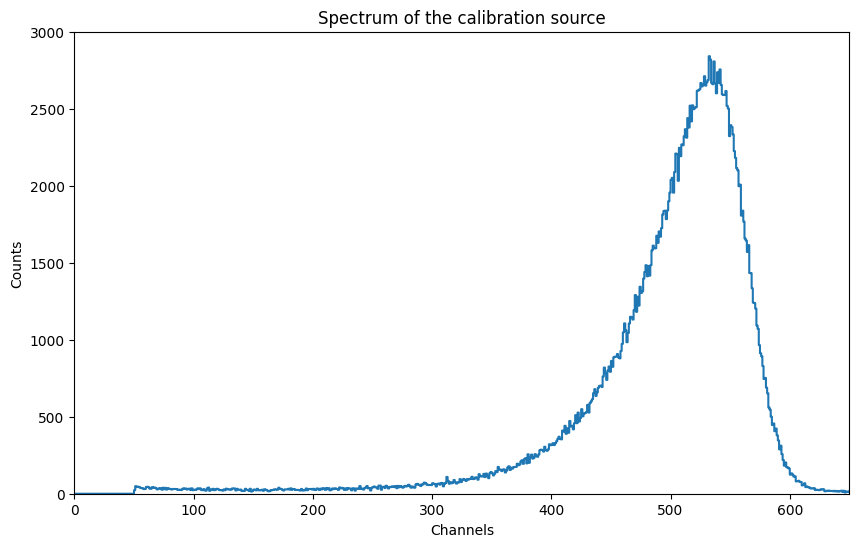

In [136]:
#Exectute to make a plot of the uncalibrated spectra.

#### NO NEED TO EDIT ####
plt.figure(figsize=(10, 6)) #make figure
# with the data read in with the first routine
plt.step(Calib_source.bin_centers, Calib_source.counts, where='mid', label='Uncal. Measurement')
plt.title("Spectrum of the calibration source") # set title of the plot
plt.xlabel("Channels")      # set label for x-axis 
plt.ylabel("Counts")        # set label for y-axis 
plt.xlim(xmin=0, xmax=650)    # -> TODO <- Might need to tune the axis scale [channels]
plt.ylim(ymin=0, ymax=3000)    #-> TODO <- Might need to tune the axis scale [counts]
plt.show()
#plt.savefig("test_spectrum.png") #This is how you save the figure
#########################

(0.0, 3500.0)

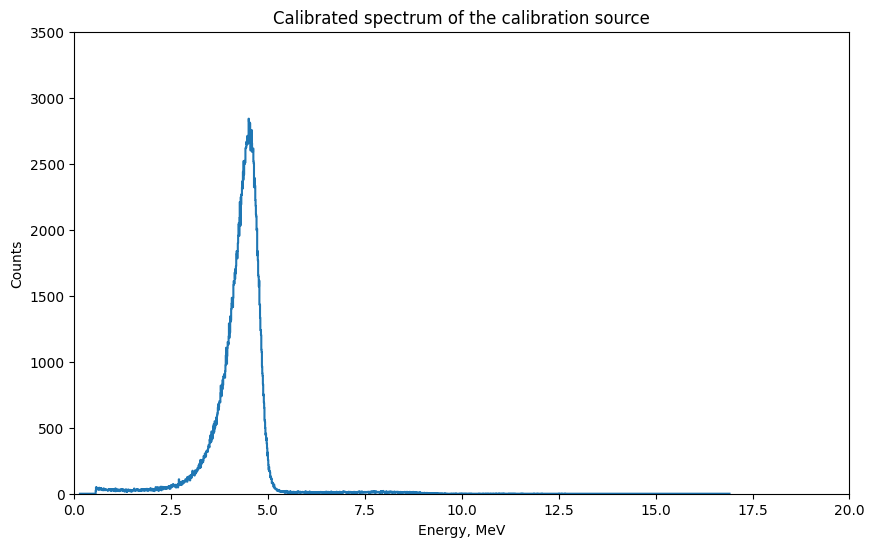

In [ ]:
#Exectute to make a plot of the calibrated spectra.

#### NO NEED TO EDIT ####
plt.figure(figsize=(10, 6)) #make figure
# with the data read in with the first routine
plt.step(Calib_source.energy, Calib_source.counts, where='mid', label='Cal. Measurement')
plt.title("Calibrated spectrum of the calibration source") # set title of the plot
plt.xlabel("Energy, MeV")   # set label for x-axis 
plt.ylabel("Counts")        # set label for y-axis 
plt.xlim(xmin=0, xmax=10)    # -> TODO <- Might need to tune the axis scale [energy]
plt.ylim(ymin=0, ymax=3500)    #-> TODO <- Might need to tune the axis scale [counts]
#plt.savefig("test_spectrum.png") #This is how you save the figure
#########################

### Step 3: Calculate the geometric efficiency of the detector

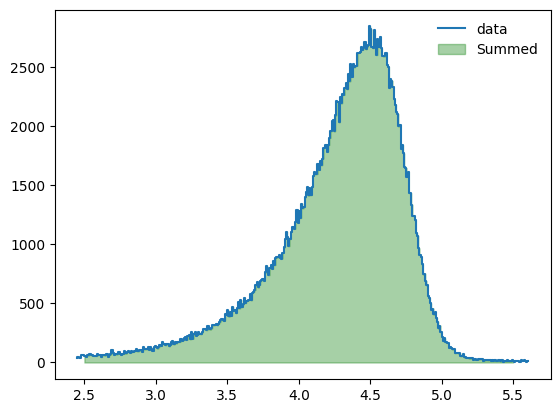

Adding between 2.5 and 5.5 gives 289668.0

 Area (intensity) of the Am-241 peak : 289668.0


In [148]:
# Summing the counts in the Am-241 peak:
Calib_source_peak = fittingFunctions.perform_counts_sum(x=Calib_source.energy,  # your x data
                                                    y=Calib_source.counts,  # your y data
                                                    region_start=2.5,   # -> TODO <- Insert energy [MeV] from where to START fitting.
                                                    region_stop=5.5    # -> TODO <- Insert energy [MeV] from where to STOP fitting.
                                                    )
print("\n Area (intensity) of the Am-241 peak : {}".format(Calib_source_peak))   

In [154]:
# Use this cell to calculate the count rate in counts per second
Count_rate = Calib_source_peak / 57
print(Count_rate)

5081.894736842105


In [162]:
# Use this cell to calculate the current activity (in Bq) of the reference source
# taking its decay into account
T_activity = 30000 


In [167]:
# Use this cell to calculate the geometric efficiency of the source
Geometric_efficiency = Count_rate/T_activity
print(Geometric_efficiency)

0.16939649122807016


## Task 2.4: Secular equilibrium

### Step 1: Determine the count of the two first peaks of the Th-228 spectrum

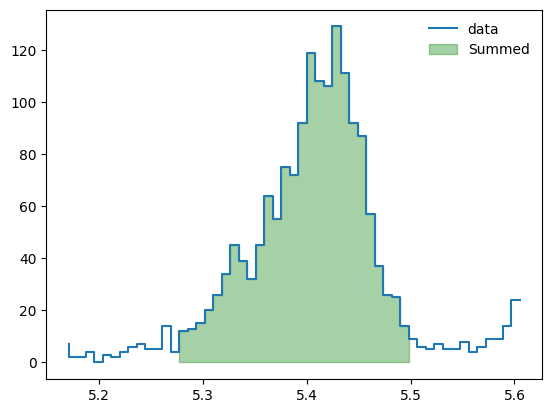

Adding between 5.27 and 5.5 gives 1554.0

 Area (intensity) of the first peak of Th-228 : 1554.0


In [174]:
# Summing the counts in the first peak of the Th-228 spectrum:
Th228_peak1 = fittingFunctions.perform_counts_sum(x=Th228.energy,  # your x data
                                                    y=Th228.counts,  # your y data
                                                    region_start=5.27,   # -> TODO <- Insert energy [MeV] from where to START fitting.
                                                    region_stop=5.5    # -> TODO <- Insert energy [MeV] from where to STOP fitting.
                                                    )
print("\n Area (intensity) of the first peak of Th-228 : {}".format(Th228_peak1))   

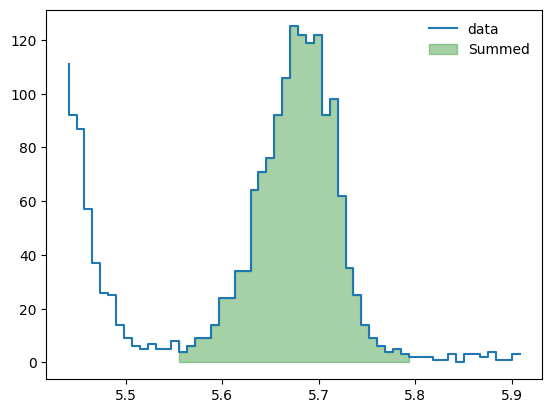

Adding between 5.55 and 5.8 gives 1416.0

 Area (intensity) of the second peak of Th-228 : 1416.0


In [175]:
# Summing the counts in the second peak of the Th-228 spectrum:
Th228_peak2 = fittingFunctions.perform_counts_sum(x=Th228.energy,  # your x data
                                                    y=Th228.counts,  # your y data
                                                    region_start=5.55,   # -> TODO <- Insert energy [MeV] from where to START fitting.
                                                    region_stop=5.8    # -> TODO <- Insert energy [MeV] from where to STOP fitting.
                                                    )
print("\n Area (intensity) of the second peak of Th-228 : {}".format(Th228_peak2))   

### Step 2: Calculate the activity in Bq of Th-228 and Ra-224

In [ ]:
# Use this cell to calculate the activity of each isotope
A_1 = Th228_peak1/(307*Geometric_efficiency)
A_2 = Th228_peak2/(307*Geometric_efficiency)
print(A_1,A_2)


29.88190141435198 27.228296269448137


## Task 2.5: Branching

In [187]:
# Use this cell to recalculate the activity of Th-228 and Ra-224 taking into account the branching
A_2_1 = A_2 * 0.0525
A_1_corrected = A_1 - A_2_1
A_2_corrected = A_2 + A_2_1
print(f"For Thorium: {A_1_corrected}")
print(f"For Radium {A_2_corrected}")

For Thorium: 28.452415860205953
For Radium 28.657781823594163


## Task 2.6: Measure the concentration of radon gas

Airflow: $13.2 \: dm^3/60s$

### Step 1: Read in the two measured spectra and calibrate

In [188]:
#Load your data files here:
Rn222_1 = MCA.load_spectrum("Rn222_1.Spe") #-> TODO <- Insert the name of your data file. Source: Rn-222 ( first measurement)
Rn222_2 = MCA.load_spectrum("Rn222_2.Spe") #-> TODO <- Insert the name of your data file. Source: Rn-222 (second measurement)

In [189]:
#Now we can use your previous calibration to calibrate this new spectra!

#### NO NEED TO EDIT ####
Rn222_1.calibrate(k, m)
Rn222_2.calibrate(k, m)
#########################

### Step 2: Produce various plots.

The following cells produce various plots, before and after calibration.

You may need to adjust the xlim values in the uncalibrated plots to better
estimate good start and stop values when summing the counts in the previous task.

(0.0, 50.0)

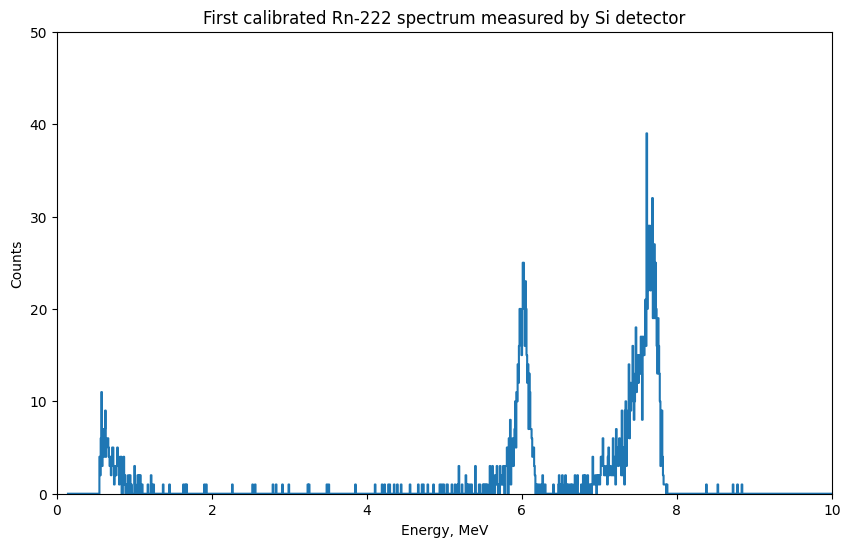

In [191]:
#Exectute to make a plot of your first calibrated Rn-222 spectra.

#### NO NEED TO EDIT ####
plt.figure(figsize=(10, 6)) #make figure
# with the data read in with the first routine
plt.step(Rn222_1.energy, Rn222_1.counts, where='mid', label='First Cal. Measurement')
plt.title("First calibrated Rn-222 spectrum measured by Si detector") # set title of the plot
plt.xlabel("Energy, MeV")   # set label for x-axis 
plt.ylabel("Counts")        # set label for y-axis 
plt.xlim(xmin=0, xmax=10)    # -> TODO <- Might need to tune the axis scale [energy]
plt.ylim(ymin=0, ymax=50)    #-> TODO <- Might need to tune the axis scale [counts]
#plt.savefig("test_spectrum.png") #This is how you save the figure
#########################

(0.0, 50.0)

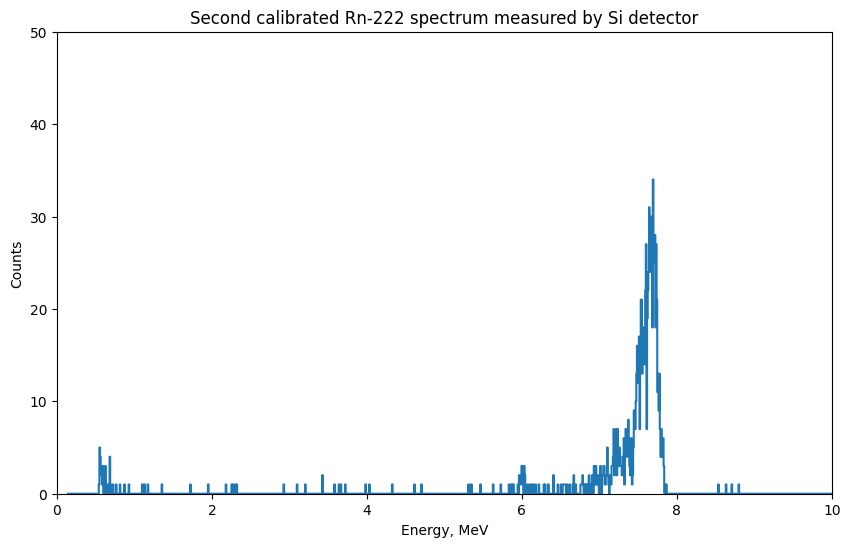

In [192]:
#Exectute to make a plot of your second calibrated Rn-222 spectra.

#### NO NEED TO EDIT ####
plt.figure(figsize=(10, 6)) #make figure
# with the data read in with the first routine
plt.step(Rn222_2.energy, Rn222_2.counts, where='mid', label='First Cal. Measurement')
plt.title("Second calibrated Rn-222 spectrum measured by Si detector") # set title of the plot
plt.xlabel("Energy, MeV")   # set label for x-axis 
plt.ylabel("Counts")        # set label for y-axis 
plt.xlim(xmin=0, xmax=10)    # -> TODO <- Might need to tune the axis scale [energy]
plt.ylim(ymin=0, ymax=50)    #-> TODO <- Might need to tune the axis scale [counts]
#plt.savefig("test_spectrum.png") #This is how you save the figure
#########################

### Step 3: Determine the counts of each peak

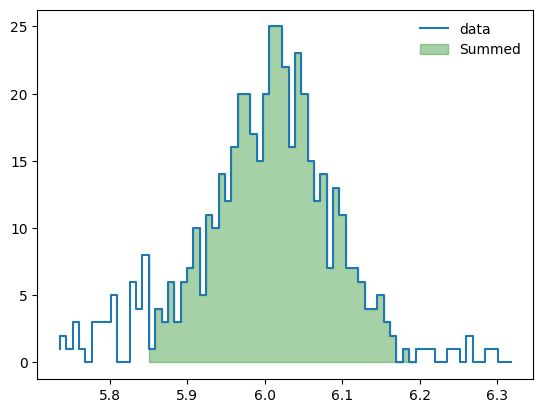

Adding between 5.85 and 6.2 gives 450.0

 Area (intensity) of the first peak of the first spectrum : 450.0


In [196]:
# Summing the 1st peak:
Rn222_1_peak1 = fittingFunctions.perform_counts_sum(x=Rn222_1.energy,  # your x data
                                                    y=Rn222_1.counts,  # your y data
                                                    region_start=5.85,   # -> TODO <- Insert energy [MeV] from where to START fitting.
                                                    region_stop=6.2    # -> TODO <- Insert energy [MeV] from where to STOP fitting.
                                                    )
print("\n Area (intensity) of the first peak of the first spectrum : {}".format(Rn222_1_peak1))

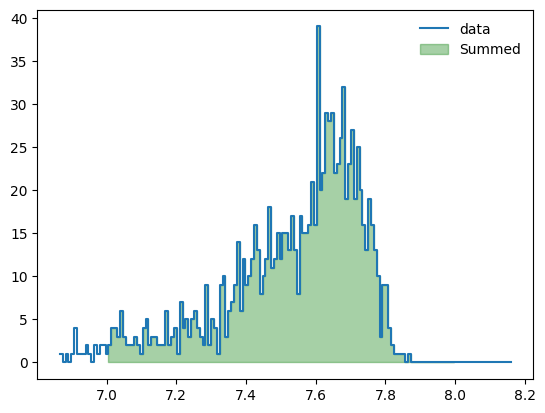

Adding between 7 and 8.0 gives 1071.0

 Area (intensity) of the second peak of the first spectrum : 1071.0


In [198]:
# Summing the 2nd peak:
Rn222_1_peak2 = fittingFunctions.perform_counts_sum(x=Rn222_1.energy,  # your x data
                                                    y=Rn222_1.counts,  # your y data
                                                    region_start=7,   # -> TODO <- Insert energy [MeV] from where to START fitting.
                                                    region_stop=8.0    # -> TODO <- Insert energy [MeV] from where to STOP fitting.
                                                    )
print("\n Area (intensity) of the second peak of the first spectrum : {}".format(Rn222_1_peak2))

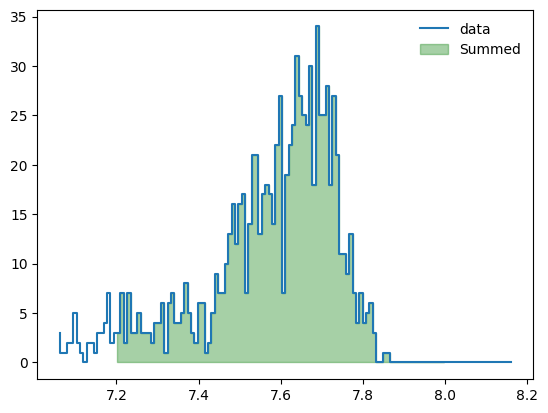

Adding between 7.2 and 8.0 gives 908.0

 Area (intensity) of the first peak of the second spectrum : 908.0


In [199]:
# Summing the 1st peak of the 2nd spectrum:
Rn222_2_peak2 = fittingFunctions.perform_counts_sum(x=Rn222_2.energy,  # your x data
                                                    y=Rn222_2.counts,  # your y data
                                                    region_start=7.2,   # -> TODO <- Insert energy [MeV] from where to START fitting.
                                                    region_stop=8.0    # -> TODO <- Insert energy [MeV] from where to STOP fitting.
                                                    )
print("\n Area (intensity) of the first peak of the second spectrum : {}".format(Rn222_2_peak2))

### Step 4: Calculate the concentration of radium decay products in collected sample 

Radium-226 decays into Radon-222 which is gaseous. In turns, Radon-222 decays and poses a health risk alongsides its decay product.

Historically these products were called RaA(Po-218), RaB(Pb-214), RaC(Bi-214), RaC'(Po-214). This is mentioned only to help should you want to try and follow the following calculation in detail as those suffixes were used to simplify variable naming

Section 1.5.5 in Nuclear physics : principles and applications - J.S. Lilley will help in understanding the following code.

In broad strokes, it is taking the known half lives and calculating how much of it is collected, how much decays in that time and then how the successive decay products feed into each other using the so-called Bateman equations.

The code is complicated, and not written in the most elegant way, but has been included for completeness, all the variables to be edited are above the `#### NO NEED TO EDIT ####`

In [202]:
collection_time = 2*60 + 52   #-> TODO <- Insert your timing [s]
transfer_time =  1*60 + 35    #-> TODO <- Insert your timing [s]
measurement_1_time = 5*60 #-> TODO <- Insert your timing [s]
decay_time = 10*60        #-> TODO <- Insert your timing [s]
measurement_2_time = 5*60 #-> TODO <- Insert your timing [s]

pump_flow =   13.2 * 60       #-> TODO <- Insert your value [l/h] 

N_A1 = 450  #-> TODO <- Insert the count of first  peak from first measurment
N_C1 = 1071  #-> TODO <- Insert the count of second peak from first measurment
N_C2 =  908 #-> TODO <- Insert the count of first  peak from second measurement

efficiency = Geometric_efficiency #-> TODO <- Insert the efficiency of the detector determined in Step 13
#### NO NEED TO EDIT ####

flow = pump_flow/1000/3600 # m3/s
t1_start = transfer_time
t1_stop = t1_start+measurement_1_time
t2_start = t1_stop+decay_time
t2_stop = t2_start+measurement_2_time
#relevant half lives
Po218_hl = 183  # [s]
Pb214_hl = 1608 # [s]
Bi214_hl = 1182 # [s]
#decay constants
lamda_A = np.log(2)/Po218_hl
lamda_B = np.log(2)/Pb214_hl
lamda_C = np.log(2)/Bi214_hl
#accumulated amounts
acc_A = 1-np.exp(-lamda_A*collection_time)
acc_B = 1-np.exp(-lamda_B*collection_time)
acc_C = 1-np.exp(-lamda_C*collection_time)
#fractional decay of components during measurment one
decay_A_1 = np.exp(-lamda_A*t1_start) - np.exp(-lamda_A*(t1_stop))
decay_B_1 = np.exp(-lamda_B*t1_start) - np.exp(-lamda_B*(t1_stop))
decay_C_1 = np.exp(-lamda_C*t1_start) - np.exp(-lamda_C*(t1_stop))                                                   
#fractional decay of components during measurment two
decay_A_2 = np.exp(-lamda_A*t2_start) - np.exp(-lamda_A*t2_stop)
decay_B_2 = np.exp(-lamda_B*t2_start) - np.exp(-lamda_B*t2_stop)
decay_C_2 = np.exp(-lamda_C*t2_start) - np.exp(-lamda_C*t2_stop)

Term12A = 1/lamda_B * (1/lamda_B * lamda_C/(lamda_C - lamda_B) * decay_B_1 * acc_B)
Term12B = 1/lamda_B * 1/lamda_C * lamda_B/(lamda_B - lamda_C) * decay_C_1 * acc_C 

Term13A_1 = 1/lamda_A * (1/lamda_A * lamda_B/(lamda_B - lamda_A) * lamda_C/(lamda_C - lamda_A) * decay_A_1 * acc_A )
Term13B_1 = 1/lamda_A * 1/lamda_B * lamda_A/(lamda_A-lamda_B) * lamda_C/(lamda_C-lamda_B) * decay_B_1 * acc_B 
Term13C_1 = 1/lamda_A * 1/lamda_C * lamda_A/(lamda_A-lamda_C) * lamda_B/(lamda_B-lamda_C) * decay_C_1 * acc_C

Term13A_2 = 1/lamda_A * (1/lamda_A * lamda_B/(lamda_B - lamda_A) * lamda_C/(lamda_C - lamda_A) * decay_A_2 * acc_A )
Term13B_2 = 1/lamda_A * 1/lamda_B * lamda_A/(lamda_A-lamda_B) * lamda_C/(lamda_C-lamda_B) * decay_B_2 * acc_B 
Term13C_2 = 1/lamda_A * 1/lamda_C * lamda_A/(lamda_A-lamda_C) * lamda_B/(lamda_B-lamda_C) * decay_C_2 * acc_C

F11 = 1/lamda_C * 1/lamda_C * decay_C_1 * acc_C
F12 = 1/lamda_B * (1/lamda_B * lamda_C/(lamda_C - lamda_B) * decay_B_1 * acc_B + 1/lamda_C * lamda_B/(lamda_B-lamda_C) * decay_C_1 * acc_C)
F13 = Term13A_1 + Term13B_1 + Term13C_1

F21 = 1/lamda_C * 1/lamda_C * decay_C_2 * acc_C
F22 = 1/lamda_B * (1/lamda_B * lamda_C/(lamda_C - lamda_B) * decay_B_2 * acc_B + 1/lamda_C * lamda_B/(lamda_B-lamda_C) * decay_C_2 * acc_C)
F23 = Term13A_2 + Term13B_2 + Term13C_2

k_denom = F22 * F11 - F21 * F12
k_1 = 1/(flow * 1/lamda_A**2 * decay_A_1 * acc_A)
k_2 = k_1 * (F21 * F13 - F23 * F11)/k_denom
k_3 = -1/flow * F21/k_denom
k_4 = 1/flow * F11/k_denom
k_5 = k_1 * (F23 * F12 - F22 * F13)/k_denom
k_6 = 1/flow * F22/k_denom
k_7 = -1/flow * F12/k_denom

C_A = k_1 * N_A1/efficiency
C_B = (k_2 * C_A + k_3 * N_C1 + k_4 * N_C2)/efficiency
C_C = (k_5 * N_A1 + k_6 * N_C1 + k_7 * N_C2)/efficiency

print("Po-218 Activity =",C_A, "Bq/m^3")
print("Pb-214 Activity =",C_B, "Bq/m^3")
print("Bi-214 Activity =",C_C, "Bq/m^3")

Po-218 Activity = 763.7474903211718 Bq/m^3
Pb-214 Activity = 346.7623629962341 Bq/m^3
Bi-214 Activity = 587.2170415183658 Bq/m^3


In [203]:
#### NO NEED TO EDIT ####

#Calculate the Equilibrium Equivalent Dose
Po218_E = 6.11
Pb214_E = 7.83
Bi214_E = 7.69 # actually energy of the proceeding 214Po decay as it's a beta decay followed quickly by alpha

# convert half life to lifetime and calculate amount of nuclei needed for 1Bq activity
potential_Po218 = Po218_hl/0.69 * (Po218_E+7.69) #second decay is short lived so included here
potential_Pb214 = Pb214_hl/0.69 * Pb214_E
potential_Bi214 = Bi214_hl/0.69 * Bi214_E

total_energy = potential_Po218+potential_Pb214+potential_Bi214 # MeV/Bq

#calculate activity concentrations
frac_Po218 = potential_Po218/total_energy
frac_Pb214 = potential_Pb214/total_energy
frac_Bi214 = potential_Bi214/total_energy


# weighting factors based on energy released per Bq of activity
C1 = frac_Po218
C2 = frac_Pb214
C3 = frac_Bi214

equilibrium_factor = 0.4 # value for indoors
#equilibrium_factor = 0.6 # value for outdoors

EEC = (C1 * C_A + C2 * C_B + C3 * C_C) / equilibrium_factor

print(EEC,"Bq/m^3")

1201.4032553531472 Bq/m^3


The International Commission on Radiological Protection (ICRP)
Give a dose coefficient of  6.7 x 10^-6 mSv per Bq h m-3

Using this and the calculateed EEC, calculate the exposure over the course of one year should this be the air in your basement


In [204]:
time_indoors = 0.8 
Dose = 6.7/1000000 * EEC * 24*365*time_indoors
print(Dose,"mSv")

56.41020789054954 mSv


**Question** : Don't forget to answer all the questions in the notebook!

# Part 3: Range of alpha particles in air
We did three background measurements for 60 seconds duration.

### Step 1: Determine the background 

In [ ]:
## compute the background measurements
#bg = [counts_BG_1, counts_BG_2, counts_BG_3] #-> TODO <- add coma separated values for the BG counts measured
bg = [16,14,19]

for i in range(0, len(bg)):
    bg[i] = ufloat(bg[i],sqrt(bg[i]))
bg = np.array(bg)
bg = np.average(bg)
print(f"Background counts {bg=:.2}")


Background counts bg=16+/-2


### Step 2: Measure the count of alpha particles from the source at various distances

It is known that the detector does not sit at $d_0=0\,\text{mm}$. For the sake of this measurements you can assume that the depth of the detector is $d_0=2.5\,\text{mm}$

The surface of the detector is quite sensitive so <font color='red'>DO NOT TRY TO MEASURE IT YOURSELVES.</font>


In [ ]:
## Format d[mm], t(s), factor, exp.Counts #-> TODO <- add the counts measured for each distance
data = [
    [ 4.5,  60, 1.00, 5221], #2mm
    [ 6.5,  60, 1.51, 3627], #4mm
    [ 8.5,  60, 2.03, 2487], #6mm
    [10.5,  60, 3.00, 1941], #8mm
    [12.5,  60, 4.01, 1417], #10mm
    [14.5,  60, 5.20, 1186], #12mm
    [16.5,  60, 6.57, 939], #14mm
    [18.5,  60, 8.12, 790], #16mm
    [20.5,  60, 9.84, 665], #18mm
    [22.5,  60, 11.7, 587], #20mm
    [24.5,  60, 13.8, 277], #22mm
    [26.5, 100, 16.1, 28], #24mm
    [28.5, 100, 18.5, 21], #26mm
    [30.5, 100, 21.1, 33], #28mm
    [32.5, 100, 24.3, 31] #30mm
]

## Turn into a dataframe using some identifying strings
s_distance=r'$d$[mm]'
s_time= r't(s)'
s_factor=r'$F_\Omega$'
s_counts_raw=r'Counts raw'
s_counts=r'Counts - BG'
s_counts_corrected=r'CPS corrected'

df = pd.DataFrame(data, columns=[s_distance, s_time, s_factor, s_counts_raw])

## Get the uncertainties into the Counts and substract the background
# The (bg/60 * t) term relates to the fact that we only collect background information for 60 seconds,
# yet later data measurements are done for 100 seconds. I.e., we are 'rescaling' the background.
df[s_counts] = [ufloat(x,sqrt(x))- (bg/60 * t) for x,t in zip(df[s_counts_raw], df[s_time])]
df[s_counts_corrected] = df[s_counts]*(1/df[s_time])*df[s_factor]
display(df)

## uncomment the following to have the output copy and paste ready
#print(df.to_latex(float_format="{:.6}".format, index=False, escape=False))

,$d$[mm],t(s),$F_\Omega$,Counts raw,Counts - BG,CPS corrected
0,4.5,60,1.00,5221,(5.20+/-0.07)e+03,86.7+/-1.2
1,6.5,60,1.51,3627,(3.61+/-0.06)e+03,90.9+/-1.5
2,8.5,60,2.03,2487,(2.47+/-0.05)e+03,83.6+/-1.7
3,10.5,60,3.00,1941,(1.92+/-0.04)e+03,96.2+/-2.2
4,12.5,60,4.01,1417,(1.40+/-0.04)e+03,93.6+/-2.5
5,14.5,60,5.20,1186,1170+/-35,101.4+/-3.0
6,16.5,60,6.57,939,923+/-31,101.0+/-3.4
7,18.5,60,8.12,790,774+/-28,105+/-4
8,20.5,60,9.84,665,649+/-26,106+/-4
9,22.5,60,11.70,587,571+/-24,111+/-5


Text(0, 0.5, 'CPS corrected')

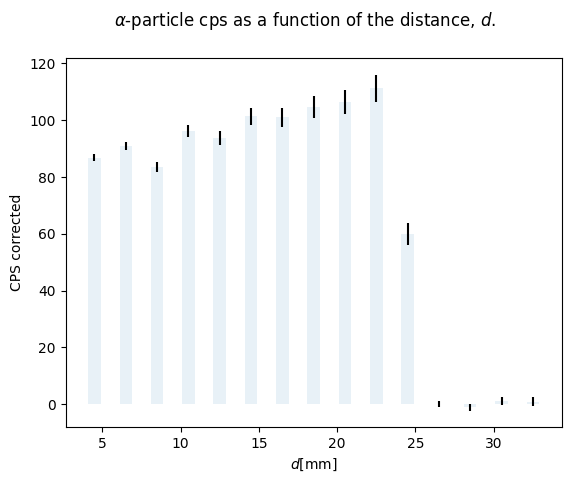

In [ ]:
import matplotlib.pyplot as plt
#                       y,x
fig, axs = plt.subplots(1,1)

fig.suptitle(r'$\alpha$-particle cps as a function of the distance, $d$.')
plt.bar(df[s_distance],
        unumpy.nominal_values(df[s_counts_corrected]),
        yerr=unumpy.std_devs(df[s_counts_corrected]),
        label='Exp.',
        alpha=0.1
       )
plt.xlabel(s_distance)
plt.ylabel(s_counts_corrected)

### Step 3 Compare the experimental value with the empiric parameterization formula

The following empiric formula can be used to calculate the range of the alpha particle in air.

$$R_\alpha[cm] = 0.318 E_\alpha^{3/2}\quad \text{for $E_\alpha$ in MeV}$$

Feel free to use this in order to cross-check that your own result in air are _similar_ (i.e. **NOT identical**). 


In [ ]:
#           This is an empirical formula which can help you estimate roughly how far the alpha
#           particle will travel in air. 
#
#           You could use this when writing your iterative code further down.

def Range_a_in_Air_Empirical(E):
    """
    E in [MeV].

    The function can be used to get an idea of roughly how far the alpha particle would travel through air.
    A brief discussion concerning the motivation behind this approximation can be found in J.S. Lilley, chapter 5.2.2. 
    
    Returns range [cm]
    """
    return 0.318*E**(3/2)

E = 5.48 # TO DO: add the energy of the alpha particle in MeV
parameterized_range = Range_a_in_Air_Empirical(E)
print(f'Alpha of {E:.4} MeV has a range of {parameterized_range:.4} cm according to parameterization')

Alpha of 5.48 MeV has a range of 4.079 cm according to parameterization


### Step 4: Compare your values with the one from Bethe-Bloch formula

The Bethe-Bloch can be written as follow:

From Lilley
$$
-\frac{dE}{dx} = \left(\frac{ze^2}{4\pi\epsilon_0}\right)^2\ \frac{4\pi Z\rho N_A}{Am_ev^2}\ \left[\ln{\left(\frac{2m_ev^2}{I}\right)} - \ln{\left(1-\beta^2\right)} - \beta^2\right]
$$

but is best coded as:

$$
-\frac{dE}{dx} = \left(\frac{e^2}{4\pi\epsilon_0}\right)^2\ 
\frac{4\pi z^2}{m_ec^2\beta^2}\ 
\frac{Z\rho N_A}{A}\ \left[\ln{\left(\frac{2m_ec^2\beta^2}{I}\right)} - \ln{\left(1-\beta^2\right)} - \beta^2\right]
$$

Using this simple variable rearranging one can see the terms more clearly as "constants", "incoming radiation properties", and "matter properties". Please have a look at the table on the Bethe-Bloch page (on Canvas) for list of the different terms.

In the cells below, you will implement the Bethe-Bloch formula step by step.

In [ ]:
#           We start off by defining the function calculating the relativistic beta value.
#           It's just the ratio of velocity and speed of light, and relates to the Lorentz factor
#           which appears in relativistic kinematics.

def Calc_Beta(E):
  """
  Projectile:
    - E [MeV]

  returns the relativistic beta value, which will be inside the interval [0, 1].
  """
  m0c2 = 3727.4 # The rest mass of an alpha particle in MeV

  # Here we compute the value of beta. 
  beta = np.sqrt(1 - 1/(E/m0c2+1)**2)

  return beta


In [ ]:
#           Here we define the Bethe-Bloch function. You can look up the "Bethe-Bloch formula" canvas page
#           for some more information about the equation and its parameters. There's also a good
#           description of the Bethe-Bloch formula in J.S. Lilley, chapter 5.2.1. 

def Bethe_Bloch(beta, z, A, Z, rho, I):
  """
  Projectile:
    - beta
    - z
  Target:
    - A  [g/mol]
    - Z  [e]
    - rho[g/cm3]
    - I [MeV]
    
  returns dE/dx in [MeV/cm] if you use the suggested units
  """

  N_A = 6.02214086E26 # Avogadro's constant
  mec2 = 0.511        # MeV
  e2_4pi_e0 = 1.4400  # MeV*fm

  # let's do some unit tweaking
  N_A  /= 1000        # 1/g
  e2_4pi_e0 /= 1E15   # MeV*m
  e2_4pi_e0 *= 100    # MeV*cm

  # Now we calculate the dE/dx. Since it can get a bit messy,
  # we split the equation into terms, calculate them separately before
  # multiplying them all together.
  term1 = e2_4pi_e0**2
  term2 = (4*np.pi*z**2)/(mec2*beta**2)
  term3 = (Z*rho*N_A)/(A)
  term4 = np.log((2*mec2*beta**2)/I) - np.log(1-beta**2) - beta**2
    
  dE_dx = term1 * term2 * term3 * term4

  return dE_dx

In [ ]:
#-> TODO <-
#           Using a series of small distance steps (dx), find the energy loss (dE)
#           of an alpha particle until it is stopped. By stopped, we mean that its
#           kinetic energy goes towards 0.
#
#           You can keep track the value of dE_dx in the 'dE_dx_array' list for plotting later.
#
#           Be creative and code what you need to get the range of an alpha particle.
#           Refer to the preparatory exercise regarding iterative loops if you are unsure about your coding (remember Mittens?).

dx = 0.00000001 #cm

E0 = 5.48# MeV

E_array = [E0]
dE_dx_array = [Bethe_Bloch(Calc_Beta(E0), 2, 28.96, 14.46, 1.225e-3, 8.6e-5 )]
depth_array = [0]

while dE_dx_array[-1]>1e-5:
    E_latest = E_array[-1]
    dE_dx_array.append(Bethe_Bloch(Calc_Beta(E_latest), 2, 28.96, 14.46, 1.225e-3, 8.6e-5 ))
    E_new = E_latest - dx * dE_dx_array[-1]
    depth_new = depth_array[-1] + dx
    E_array.append(E_new)
    depth_array.append(depth_new)




#-> TODO <- Write some iterative logic to solve for the distance traveled by the alpha particle.

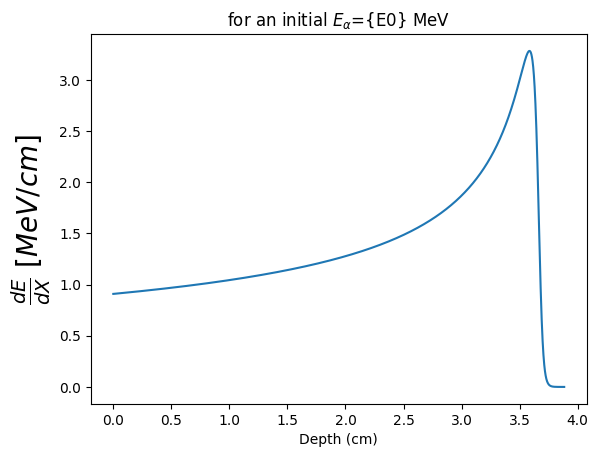

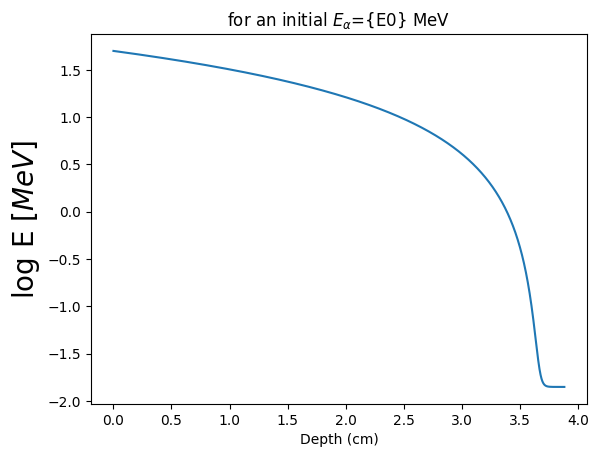

In [ ]:
#-> TODO <-
#           You can use this section to plot your data. Note that you may need to change
#           variable names and/or labels/titles.

# Here we convert regular python lists into np.arrays.
# This allows us to perform nifty operations (such as multipying with a scalar).
# Hence, if you want to change units you can just multiply the array with an appropriate value.
# E.g., MeV -> eV: E_array = E_array * 1E6
E_array = np.array(E_array)
dE_dx_array = np.array(dE_dx_array)

plt.figure()
plt.plot(depth_array, dE_dx_array)
plt.xlabel(r'Depth (cm)')
plt.ylabel(r'$\frac{dE}{dX}$ $[MeV/cm]$', size=20)
plt.title(r'for an initial $E_\alpha$={E0} MeV')
plt.show
#plt.savefig("bethe_bloch_E.svg")

plt.figure()
plt.plot(depth_array, np.log(E_array))
plt.xlabel(r'Depth (cm)')
plt.ylabel(r'log E $[MeV]$', size=20)
plt.title(r'for an initial $E_\alpha$={E0} MeV')
plt.show()
#plt.savefig("bethe_bloch_dE_dX.svg")

### Step 5: Gold thickness

By now you may have noticed that the _measured_ distance traveled by the alpha particle differs quite a bit from the _calculated_ one. We **think** it might be due to a (very) thin layer of gold being placed on top of the source. 
Your task is to find the thickness of this presummed gold layer.

Tip: the distance will be smaller in gold that in air. You may need to adjust the steps of your loop.

In [ ]:
# -> TODO <-
#           Estimate the thickness of the gold foil using the Bethe–Bloch formula.
#           There are several valid approaches, but note that the foil thickness
#           is expected to be very small so the "steps" in the calculation need to
#           be reduced accordingly.
#
#           Hint: Discuss your strategy with other peers and/or the TAs.

R = 2.2

E = (R/0.317)**(2/3)

print(E0)
E_array = [E0]
dE_dx_array = [Bethe_Bloch(Calc_Beta(E0), 2, 196.96657, 79, 19.3, 79*(9.76 + 58.8*79**(-1.19))*1e-6  )]
depth_array = [0]

while E_array[-1]-E>1e-4:
    E_latest = E_array[-1]
    dE_dx_array.append(Bethe_Bloch(Calc_Beta(E_latest), 2, 196.96657, 79, 19.3, 79*(9.76 + 58.8*79**(-1.19))*1e-6  ))
    E_new = E_latest - dx * dE_dx_array[-1]

    depth_new = depth_array[-1] + dx
    E_array.append(E_new)
    
    depth_array.append(depth_new)

print(depth_array[-1])


5.48
0.00041700000000000363


The thickness of the gold layer is $4.2 \: \mu m$